<a href="https://www.kaggle.com/code/deepshrestha/notebook812bf96ea0?scriptVersionId=331027895" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rakeshrau/social-network-ads/Social_Network_Ads.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/rakeshrau/social-network-ads/Social_Network_Ads.csv")

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df["Gender"]=df["Gender"].replace({"Male":0, "Female":1})


/tmp/ipykernel_16/2949928546.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"]=df["Gender"].replace({"Male":0, "Female":1})


In [5]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,0,19,19000,0
1,15810944,0,35,20000,0
2,15668575,1,26,43000,0
3,15603246,1,27,57000,0
4,15804002,0,19,76000,0


In [6]:
x=df.iloc[:,1:4].values
y=df.iloc[:,-1].values

In [7]:
x

array([[    0,    19, 19000],
       [    0,    35, 20000],
       [    1,    26, 43000],
       ...,
       [    1,    50, 20000],
       [    0,    36, 33000],
       [    1,    49, 36000]], shape=(400, 3))

In [8]:
y

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [10]:
x=scaler.fit_transform(x)
x

array([[-1.02020406, -1.78179743, -1.49004624],
       [-1.02020406, -0.25358736, -1.46068138],
       [ 0.98019606, -1.11320552, -0.78528968],
       ...,
       [ 0.98019606,  1.17910958, -1.46068138],
       [-1.02020406, -0.15807423, -1.07893824],
       [ 0.98019606,  1.08359645, -0.99084367]], shape=(400, 3))

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [12]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)


DecisionTreeClassifier()

In [13]:
y_pred=dt.predict(x_test)

In [14]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred,y_test))

0.8625


[Text(0.5325797872340425, 0.9615384615384616, 'x[1] <= 0.463\ngini = 0.467\nsamples = 320\nvalue = [201, 119]'),
 Text(0.35106382978723405, 0.8846153846153846, 'x[2] <= 0.61\ngini = 0.282\nsamples = 224\nvalue = [186, 38]'),
 Text(0.4418218085106383, 0.9230769230769231, 'True  '),
 Text(0.23404255319148937, 0.8076923076923077, 'x[1] <= -0.11\ngini = 0.072\nsamples = 188\nvalue = [181, 7]'),
 Text(0.2127659574468085, 0.7307692307692307, 'gini = 0.0\nsamples = 129\nvalue = [129, 0]'),
 Text(0.2553191489361702, 0.7307692307692307, 'x[2] <= 0.228\ngini = 0.209\nsamples = 59\nvalue = [52, 7]'),
 Text(0.14893617021276595, 0.6538461538461539, 'x[2] <= -0.051\ngini = 0.113\nsamples = 50\nvalue = [47, 3]'),
 Text(0.1276595744680851, 0.5769230769230769, 'gini = 0.0\nsamples = 29\nvalue = [29, 0]'),
 Text(0.1702127659574468, 0.5769230769230769, 'x[1] <= 0.367\ngini = 0.245\nsamples = 21\nvalue = [18, 3]'),
 Text(0.1276595744680851, 0.5, 'x[1] <= 0.081\ngini = 0.188\nsamples = 19\nvalue = [17, 2]'

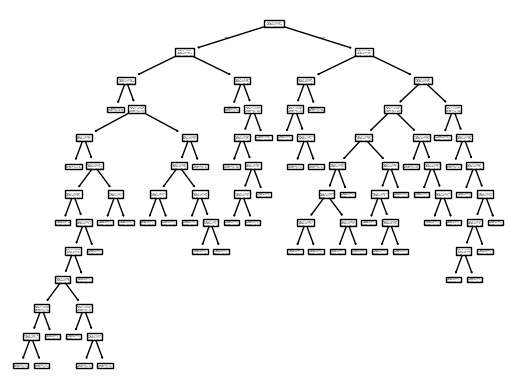

In [15]:
from sklearn.tree import plot_tree
plot_tree(dt)

# Now, Hyper paramater tuning on decision tree hyperparameters using GridSearch

In [16]:
params={
    "criterion":["gini","entropy"],
    "max_depth":[1,2,3,4,5,6,7,None]
}

In [17]:
from sklearn.model_selection import GridSearchCV
gridSearch=GridSearchCV(dt,params,cv=10,n_jobs=-1)

In [18]:
gridSearch.fit(x_train,y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, None]})

In [19]:
gridSearch.best_estimator_

DecisionTreeClassifier(max_depth=2)

In [20]:
gridSearch.best_params_

{'criterion': 'gini', 'max_depth': 2}

In [21]:
gridSearch.best_score_

np.float64(0.9125)

In [22]:
dt1=DecisionTreeClassifier(criterion="gini",max_depth=3)

In [23]:
dt1.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [24]:
y_pred1=dt1.predict(x_test)

In [25]:
print(accuracy_score(y_pred1,y_test))

0.9125


[Text(0.5, 0.875, 'x[1] <= 0.463\ngini = 0.467\nsamples = 320\nvalue = [201, 119]'),
 Text(0.25, 0.625, 'x[2] <= 0.61\ngini = 0.282\nsamples = 224\nvalue = [186, 38]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[1] <= -0.11\ngini = 0.072\nsamples = 188\nvalue = [181, 7]'),
 Text(0.0625, 0.125, 'gini = 0.0\nsamples = 129\nvalue = [129, 0]'),
 Text(0.1875, 0.125, 'gini = 0.209\nsamples = 59\nvalue = [52, 7]'),
 Text(0.375, 0.375, 'x[1] <= -1.065\ngini = 0.239\nsamples = 36\nvalue = [5, 31]'),
 Text(0.3125, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4375, 0.125, 'gini = 0.202\nsamples = 35\nvalue = [4, 31]'),
 Text(0.75, 0.625, 'x[2] <= -0.917\ngini = 0.264\nsamples = 96\nvalue = [15, 81]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[1] <= 0.845\ngini = 0.064\nsamples = 30\nvalue = [1, 29]'),
 Text(0.5625, 0.125, 'gini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.6875, 0.125, 'gini = 0.0\nsamples = 24\nvalue = [0, 24]'),
 Text(0.875, 0.375, 'x[2] <=

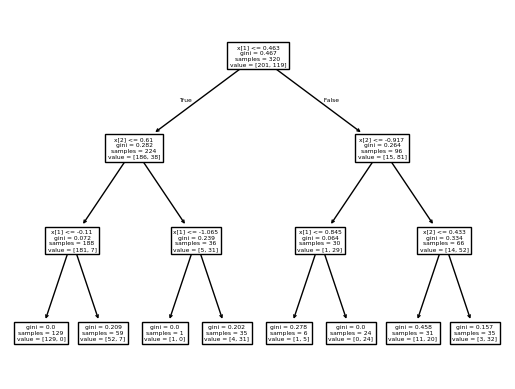

In [26]:
plot_tree(dt1)